# Documentation

This file plots the 'Qobs' SST pattern from Neale and Hoskins (2000), used in the Aqua-planet simulations performed by Mu-Ting Chien

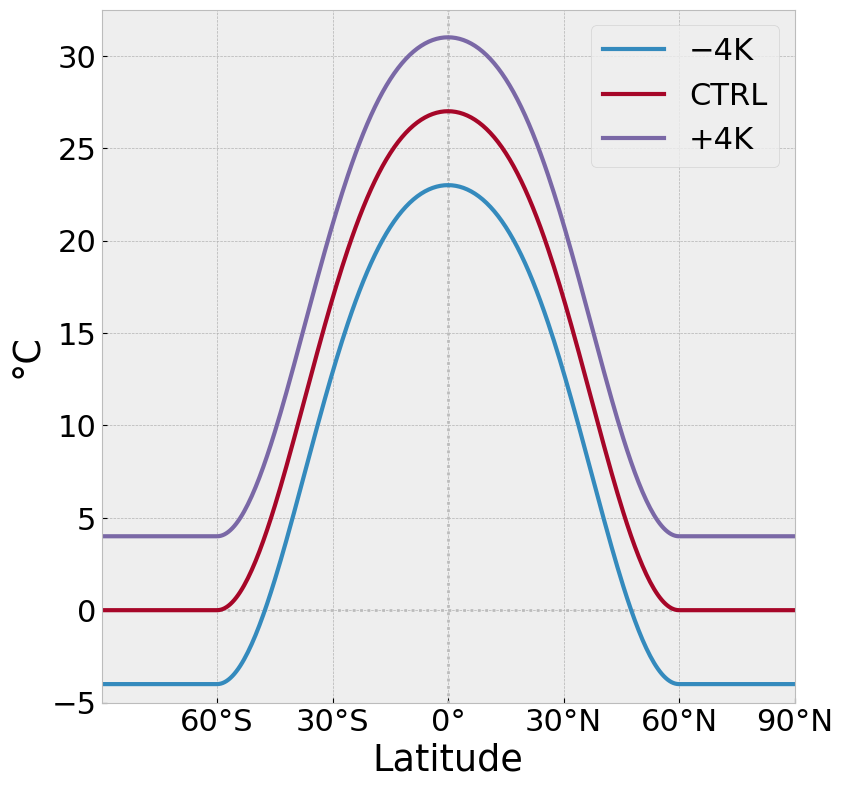

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
sys.path.insert(0, "/glade/u/home/sressel/auxiliary_functions/")
from config import *
from bmh_colors import bmh_colors
from tick_labeller import tick_labeller

phi = np.arange(-90, 90.5, 0.5)
SST = np.zeros_like(phi)
SST[np.abs(phi) <= 60] = 27*(
    1
    - 0.5*(np.sin(np.pi*phi[np.abs(phi) <= 60]/120)**2)
    - 0.5*(np.sin(np.pi*phi[np.abs(phi) <= 60]/120)**4)
)

plt.style.use('bmh')
plt.rcParams.update({'font.size':22})
[fig, ax] = plt.subplots(1, 1, figsize=(9,9))
# ax.set_title("Aqua-planet SST Boundary Condition", pad=10)
ax.axhline(y=0, ls=':', color='#bcbcbc')
ax.axvline(x=0, ls=':', color='#bcbcbc')
ax.plot(
    phi,
    SST-4,
    color=bmh_colors(1),
    label=experiments_array.sel(experiment='-4K')['name'].item(),
    lw=3
)

ax.plot(
    phi,
    SST,
    color=bmh_colors(2),
    label=experiments_array.sel(experiment='0K')['name'].item(),
    lw=3
)

ax.plot(
    phi,
    SST+4,
    color=bmh_colors(3),
    label=experiments_array.sel(experiment='4K')['name'].item(),
    lw=3
)


ax.legend(loc='best')
ax.set_xlim(-90,90)
ax.set_xticks(np.arange(-90, 90+30, 30), labels=tick_labeller(np.arange(-90, 90+30, 30), 'lat', precision=0), ha='center')
ax.set_xlabel('Latitude')
ax.xaxis.set_major_locator(mticker.MaxNLocator(7, prune="lower"))
ax.set_ylim(-5, 32.5)
ax.set_yticks(np.arange(-5, 35, 5))
ax.set_ylabel("°C")
ax.set_aspect(np.abs((ax.get_xlim()[1] - ax.get_xlim()[0])/(ax.get_ylim()[1] - ax.get_ylim()[0])))
# plt.show()

# plt.savefig(f"{aquaplanet_output_directory}/SST_pattern.png", dpi=500)